In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

## Train a single model

#### Load the training and testing datasets and tokenize them

In [ ]:

VOCAB_SIZE = 100
N_TRAIN = 2*40_000
N_TEST = 1000

from models import ChronosTokenizer
tokenizer = ChronosTokenizer(VOCAB_SIZE, -3, 3)

traj_train = np.load("data/traj_train.pkl", allow_pickle=True)
x_train = traj_train[:, 0]
tok_train, aux = tokenizer.encode_series(x_train, 100, 10)

traj_test = np.load("data/traj_test.pkl", allow_pickle=True)
x_test = traj_test[:, 0]
tok_test, aux = tokenizer.encode_series(x_test, 100, 10)


traj_test_out = np.load("data/traj_test_out.pkl", allow_pickle=True)
x_test_out = traj_test_out[:, 0]
tok_test_out, aux = tokenizer.encode_series(x_test_out, 100, 10)



### Import the model and train it

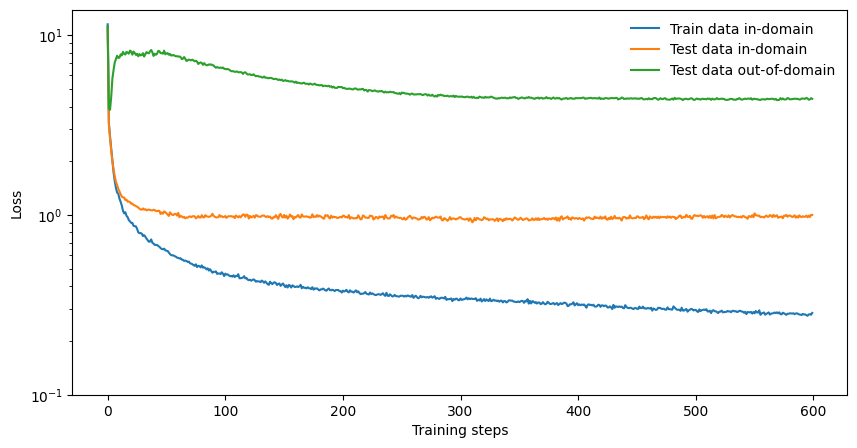

In [ ]:
import torch
from models import TinyCausalLM, train_next_token

CONTEXT_LENGTH = 32*4

torch.manual_seed(0)
tokens = torch.tensor(tok_train, dtype=torch.long)
tokens_val = torch.tensor(tok_test, dtype=torch.long)
tokens_test_out = torch.tensor(tok_test_out, dtype=torch.long)
model, losses, val_losses, val_losses_ood = train_next_token(
    tokens, tokens_val[:N_TEST], tokens_test_out[:N_TEST], vocab_size=(1 + VOCAB_SIZE), 
    block_size=CONTEXT_LENGTH, lr=1e-4, batch_size=64*2, steps=60000, 
    d_model=128 * 2, d_k=64, weight_decay=1e0,
    save_path="./private_data/training_run/"
    )

plt.figure(figsize=(10, 5))
plt.semilogy(losses, label="Train data in-domain")
plt.semilogy(val_losses, label="Test data in-domain")
plt.semilogy(val_losses_ood, label="Test data out-of-domain")
plt.ylim(1e-1, None)
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.legend(frameon=False)


## Optionally save the model
# from models import save_checkpoint
# losses = np.array([losses, val_losses, val_losses_ood]).T
# losses.dump(f"losses.npz")
# ckpt_name = f"tiny_lm.pt"
# save_checkpoint(ckpt_name, model)



Text(0.5, 1.0, 'Out-of-domain')

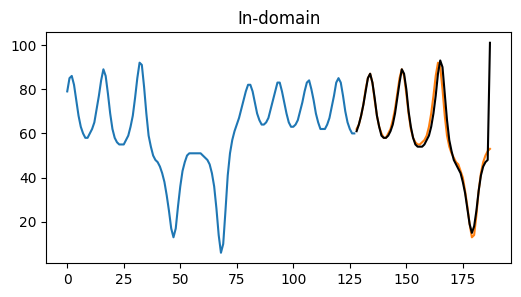

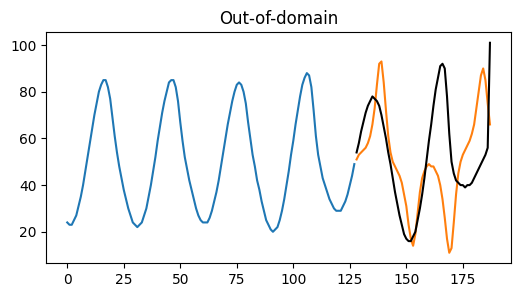

In [ ]:
from models import generate_autoregressive

context_length = model.block_size
horizon = 60
t_inds = np.arange(context_length + horizon)

## In-distribution
ctx = torch.tensor(tok_test[-(context_length+horizon):-horizon], dtype=torch.long)  # (T,)
out = generate_autoregressive(model, ctx, max_new_tokens=horizon, greedy=True).squeeze()#[:horizon]

## Out-of-distribution
ctx_ood = torch.tensor(tok_test_out[-(context_length+horizon):-horizon], dtype=torch.long)  # (T,)
out_ood = generate_autoregressive(model, ctx_ood, max_new_tokens=horizon, greedy=True).squeeze()#[:horizon]

plt.figure(figsize=(6, 3))
plt.plot(t_inds[:context_length], out.tolist()[:context_length])
plt.plot(t_inds[context_length:context_length+horizon], out.tolist()[context_length:context_length+horizon])
plt.plot(t_inds[context_length:context_length+horizon], tok_test[-horizon:], color='black')
plt.title("In-domain")

plt.figure(figsize=(6, 3))
plt.plot(t_inds[:context_length], out_ood.tolist()[:context_length])
plt.plot(t_inds[context_length:context_length+horizon], out_ood.tolist()[context_length:context_length+horizon])
plt.plot(t_inds[context_length:context_length+horizon], tok_test_out[-horizon:], color='black')
plt.title("Out-of-domain")